# VEP Analysis

In [2]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

In [3]:
### Attempts to add new slots to the xarray dataset ###

# import xarray as xr

# xr_ds = xr.open_dataset(xr_ds_path, mode="a-")

# new_slots=  np.append(xr_ds.coords["slot"].data, "delta_pow2_mean")
# print(new_slots)
# xr_ds["flashzoi"].assign_coords({"slot": ("slot", new_slots)})

## Import non-null VEP results

In [3]:
variant_set="clinvar_utr_snv_test2"
xr_ds_path = os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set,
    "chr22.zarr"
)

vep_df = vp.load_vep_results(xr_ds_path=xr_ds_path, 
                             dropna_subset=["flashzoi"])
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Contents of xarray after filtering [filled values / total values]:
 - rows: 19423380
 - sites: 381 / 382
 - samples: 2549 / 2549
 - ploid: 2 / 2
 - slots: 10 / 14


,site,sample,ploid,slot,dnabert2,evo2_7b_base,spliceai_mm,evo2_40b,spliceai,evo2_40b_base,evo2_7b,flashzoi
0,chr22:28734637-28734638_G_A,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.428021
4,chr22:28734637-28734638_G_A,REF,0,delta_abs_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000417
5,chr22:28734637-28734638_G_A,REF,0,delta_max_max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.524804
6,chr22:28734637-28734638_G_A,REF,0,delta_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000008
7,chr22:28734637-28734638_G_A,REF,0,delta_pow2_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000007


## Estimate total time

Based on the existing results, estimate how long it will take to run all selected ClinVar variants. 

In [4]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 
va.estimate_runtime(vep_df,
                     total_sites=bed_utr["name"].n_unique(),
                     model_name="flashzoi",
                     time_col="time_total",
                     n_gpus=1)

Extracting ID columns.
Adding ID counts.


NameError: name 'vep_df' is not defined

In [6]:
bed_utr.head()

chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i64,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",2,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""


Count the number of samples per site (should be all identical). 

In [5]:
vep_df.groupby("site")["sample"].nunique().describe()

count     381.0
mean     2549.0
std         0.0
min      2549.0
25%      2549.0
50%      2549.0
75%      2549.0
max      2549.0
Name: sample, dtype: float64

In [6]:
vep_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
COVR,351762.0,0.988208,1.079982,0.000000,0.499637,0.727098,1.128604,7.441418
delta_abs_mean,351762.0,0.000902,0.001100,0.000000,0.000303,0.000514,0.000972,0.009696
delta_max_max,351762.0,1.188435,2.064480,0.000000,0.316241,0.603809,0.946747,20.563545
delta_mean,351762.0,-0.000111,0.000842,-0.006743,-0.000224,-0.000018,0.000120,0.002379
delta_pow2_mean,351762.0,0.000095,0.000286,0.000000,0.000004,0.000009,0.000052,0.002060
len_seq_mut,351762.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
len_seq_wt,351762.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
output_length,351762.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
time_run_vep,351762.0,0.038490,0.002607,0.035428,0.037211,0.037764,0.039039,0.061534


Plot a sampling of the various slot values, including different VEP metrics and metadata about how long each iteration took to run.

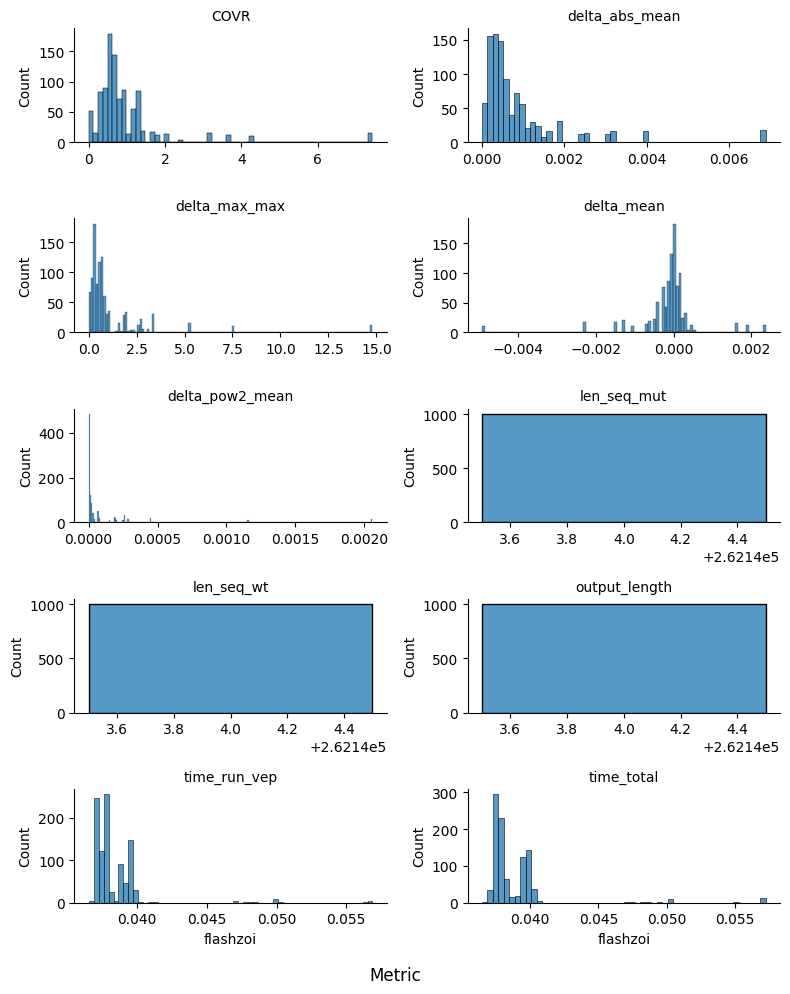

In [7]:
def summary_histograms(vep_df,
                       slot_col="slot", 
                       x="flashzoi",
                       height=2,
                       aspect=2, 
                       col_wrap=2,
                       margin_titles=True,
                       sharex=False,
                       sharey=False, 
                       sample_size=1000):

    # Create a figure with subplots for each slot
    g = sns.FacetGrid(vep_df.groupby(slot_col).sample(sample_size).sort_values(slot_col),
                    col=slot_col,  # Changed from row to col
                    col_wrap=col_wrap,  # Added col_wrap to wrap facets
                    height=height, 
                    aspect=aspect, 
                    margin_titles=margin_titles,
                    sharex=sharex, 
                    sharey=sharey)
    g.map_dataframe(sns.histplot, x=x)
    g.set_titles("{col_name}")
    g.fig.supxlabel("Metric")
    plt.tight_layout()

summary_histograms(vep_df)


## Annotate VEP results with variant metadata

### Parse Disease IDs

In [3]:
import src.owlready2 as OWL

onto = OWL.get_onto_mondo()

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.


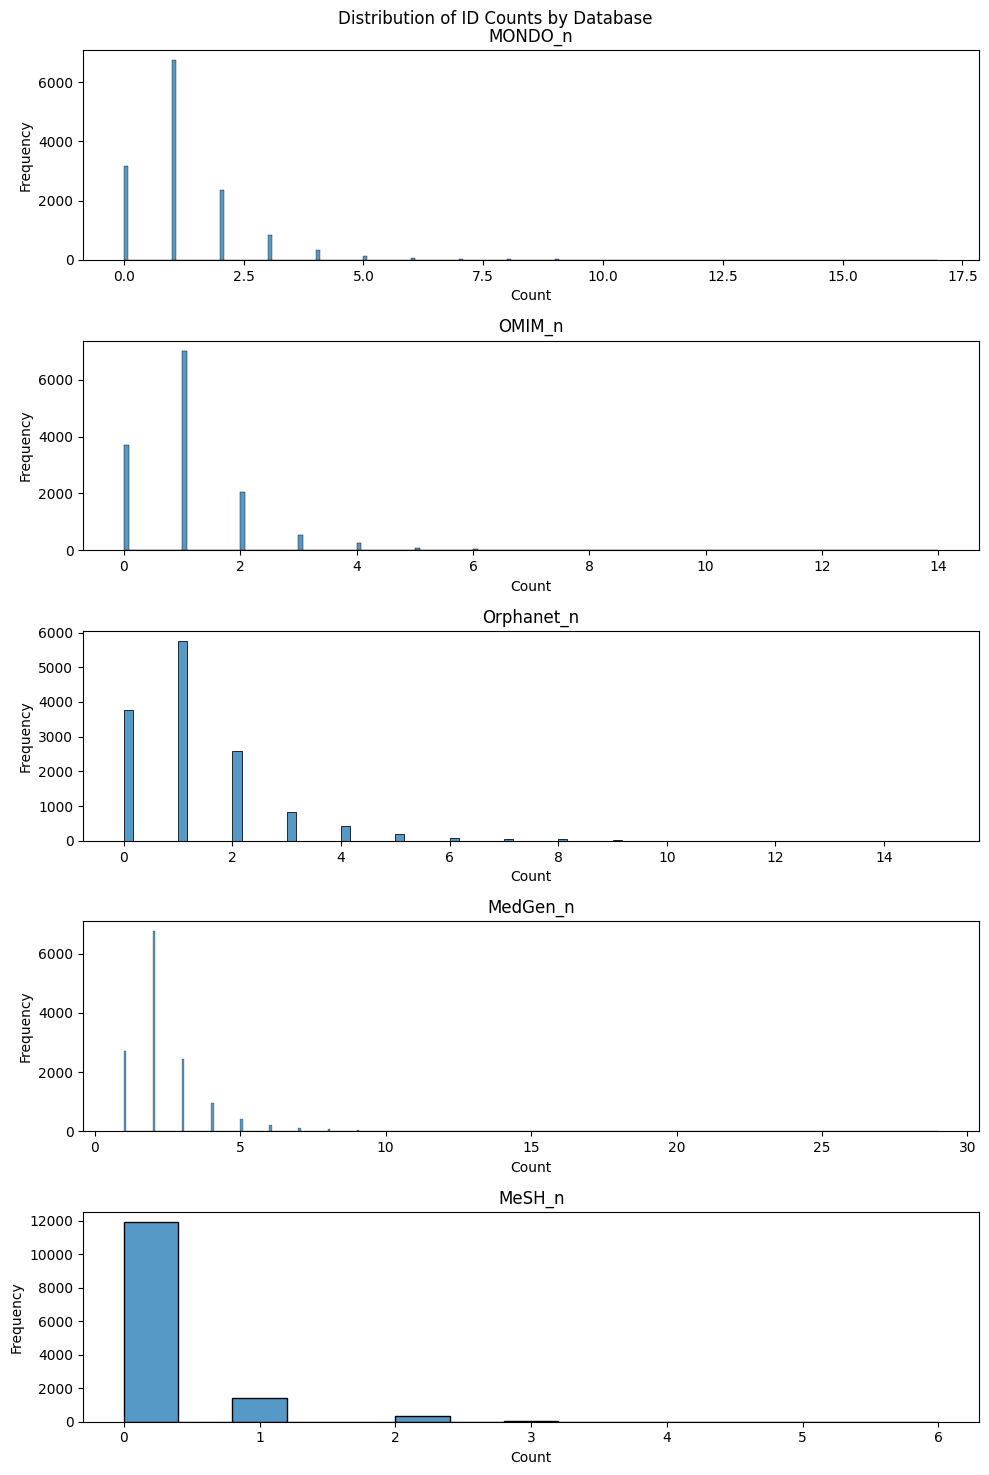

chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,OMIM,Orphanet,MedGen,MeSH,MONDO_n,OMIM_n,Orphanet_n,MedGen_n,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,list[str],list[str],list[str],list[str],list[str],u32,u32,u32,u32,u32,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""",1,15842,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014502""]","[""OMIM:616126""]","[""Orphanet:319563""]","[""MedGen:C3661900"", ""MedGen:C4015293"", ""MedGen:CN169374""]",[],1,1,1,3,0,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,3121561,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014052""]","[""OMIM:615120""]","[""Orphanet:590""]","[""MedGen:CN169374"", ""MedGen:C3808739"", ""MedGen:C3661900""]",[],1,1,1,3,0,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,2465136,null,null,null,null,null,null,null,null,null,2,[],[],[],"[""MedGen:C3661900""]",[],0,0,0,1,0,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,2710872,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014052""]","[""OMIM:615120""]","[""Orphanet:590""]","[""MedGen:C3808739"", ""MedGen:C3661900""]",[],1,1,1,2,0,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,4308920,null,null,null,null,null,null,null,null,null,2,[],[],[],"[""MedGen:C3661900""]",[],0,0,0,1,0,"""benign""","""benign""","""AGRN"""


In [6]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", 
                      extract_ids=True,
                      simplify=True) 

# Create histograms for each ID count column
id_cols = ['MONDO_n', 'OMIM_n', 'Orphanet_n', 'MedGen_n', 'MeSH_n']
fig, axes = plt.subplots(len(id_cols), 1, figsize=(10, 15))
fig.suptitle('Distribution of ID Counts by Database')

for idx, col in enumerate(id_cols):
    sns.histplot(data=bed_utr.to_pandas(), x=col, ax=axes[idx])
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Count')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

bed_utr.head()


In [8]:
# Get counts of the most common pairwise MRCAs from a list of MONDO IDs
mondo_ids = bed_utr.explode("MONDO").drop_nulls("MONDO")["MONDO"].str.replace("MONDO:MONDO:","MONDO:").to_list()[:10]
sorted_mrcas = OWL.get_mrca_counts(onto, ids=mondo_ids)
print(sorted_mrcas)

anc = OWL.get_ancestors(onto,
                 id=["MONDO:0005148",'MONDO:0100545'], 
                 prefix="MONDO", 
                 return_ids=True,
                 lvl=1)

anc

[('MONDO:0003847', 23), ('BFO:0000016', 9), ('MONDO:0100545', 6), ('MONDO:0014958', 3), ('MONDO:0032931', 3), ('MONDO:0014052', 1)]


['MONDO:0002908', 'MONDO:0100545']

In [9]:
# import src.owlready2 as OWL
# from tqdm import tqdm

# # Get filtered dataframe
# filtered_df = bed_utr.filter(pl.col("MONDO_n")>0)

# # Create progress bar
# pbar = tqdm(total=len(filtered_df), desc="Processing MONDO ancestors")

# # Apply function with progress bar
# result = filtered_df.with_columns(
#     pl.col("MONDO").map_elements(
#         lambda x: (
#             pbar.update(1),
#             OWL.get_ancestors(onto,
#                             id=x,
#                             prefix="MONDO", 
#                             return_ids=True,
#                             # verbose=True,
#                             lvl=1)
#         )[1],  # Return only the ancestors result, not the progress update
#         return_dtype=pl.List(pl.String)
#     ).alias("ancestors")
# )

# # Close progress bar
# pbar.close()

In [32]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 

print("bed shape:",bed_utr.shape)
print("vep_df shape:",vep_df.shape)

print(bed_utr["ONC"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIGCONF"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_simple"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_super_simple"].value_counts().sort(by="count", descending=True))

bed shape: (13771, 38)
vep_df shape: (19423380, 12)
shape: (4, 2)
┌────────────────────────┬───────┐
│ ONC                    ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ null                   ┆ 13735 │
│ Oncogenic              ┆ 20    │
│ Likely_oncogenic       ┆ 15    │
│ Uncertain_significance ┆ 1     │
└────────────────────────┴───────┘
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ Pathogenic                      ┆ 846   │
│ Likely_pathogenic               ┆ 288   │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|other                    ┆ 1     

In [35]:
# Filter rows and merge variant metadata from BED file
delta_df = vep_df.loc[(vep_df["slot"].str.startswith("delta_") | vep_df["slot"].str.startswith("COVR"))].copy().merge(
    bed_utr.to_pandas(), 
                       left_on="site", 
                       right_on="name")

print("Merged vep_df/bed shape:",delta_df.shape)
print("\n",delta_df["ONC"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIGCONF"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG_simple"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG_super_simple"].value_counts().sort_values(ascending=False))

Merged vep_df/bed shape: (9711690, 50)

 Series([], Name: count, dtype: int64)

 CLNSIG
Benign                          5964660
Likely_benign                   1121560
Benign/Likely_benign             917640
Pathogenic/Likely_pathogenic     815680
Pathogenic                       790190
Likely_pathogenic                 76470
Benign|other                      25490
Name: count, dtype: int64

 Series([], Name: count, dtype: int64)

 CLNSIG_simple
benign           5990150
likely_benign    2039200
likely_path       892150
path              790190
Name: count, dtype: int64

 CLNSIG_super_simple
benign    8029350
path      1682340
Name: count, dtype: int64


Preprocess VEP data and add normalized column. 

In [9]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
scaler = RobustScaler()
# scaler = Normalizer()

# Group by site and slot, then apply minmax scaling
delta_df.loc[:,"flashzoi_norm"] = delta_df.groupby(["GENE","slot"])["flashzoi"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
)

 # Sort by scoring strategy
clinsig_col="CLNSIG_simple"
delta_df = utils.sort_by_reverse_string(delta_df, 
                                        column='slot',
                                        extra_sort_cols=[clinsig_col],
                                        ascending=[True, False])

NameError: name 'delta_df' is not defined

In [8]:
def plot_violin(df,
                x="CLNSIG_simple",
                y="flashzoi",
                hue="CLNSIG_simple",
                row=None,#"GENE",
                col="slot",
                palette=utils.get_clinsig_palette(),
                cut=0,
                height=3,
                aspect=1,
                sharey=False,
                sharex=True, 
                **kwargs):
    # Filter for delta metrics and create violin plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex, 
                    margin_titles=True)
    g.map_dataframe(sns.violinplot, 
                    x=x, 
                    y=y, 
                    hue=hue,
                    palette=palette,
                    cut=cut,
                    **kwargs)
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    g.set_titles(row_template="{row_name}", col_template=
                 "{col_name}")
    for ax in g.axes.flat:
        plt.setp(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_kde(df,
             x="flashzoi",
             hue="CLNSIG_simple",
             row="slot",
             col=None, 
             height=3,
             aspect=2,
             alpha=.75,
             fill=True,
             legend=True, 
             sharey=False,
             sharex=False,
             **kwargs):
    # Filter for delta metrics and create 2D density plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex)
    g.map_dataframe(sns.kdeplot, 
                    x=x, 
                    hue=hue,
                    palette=utils.get_clinsig_palette(),
                    alpha=alpha,
                    fill=fill,  # Fill the KDE plot
                    legend=legend,
                    **kwargs)
    g.set_titles("{row_name}")
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    plt.tight_layout()

    # Add legend with explicit legend handles
    handles, labels = g.axes[0,0].get_legend_handles_labels()
    g.fig.legend(handles, labels, title="Clinical Significance", 
                bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.show()
    

Violin plot

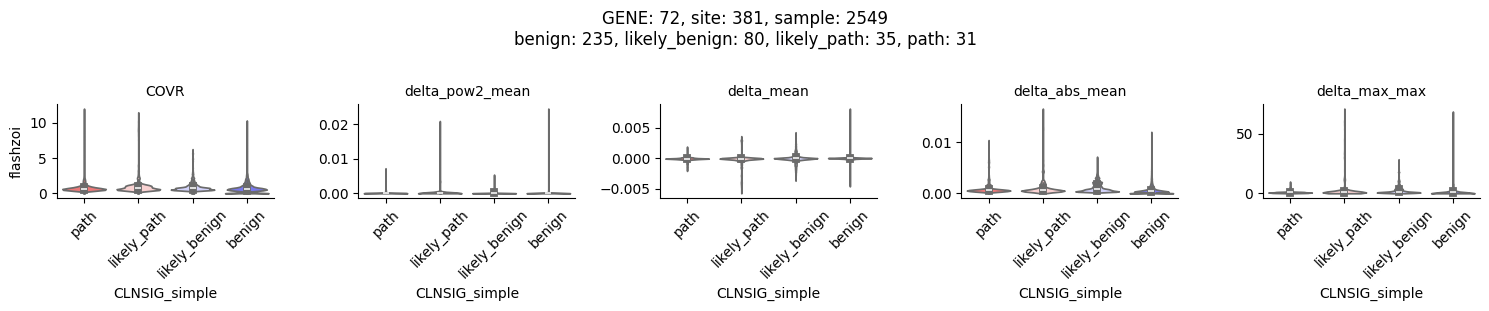

In [11]:
plot_violin(delta_df, hue="CLNSIG_simple")

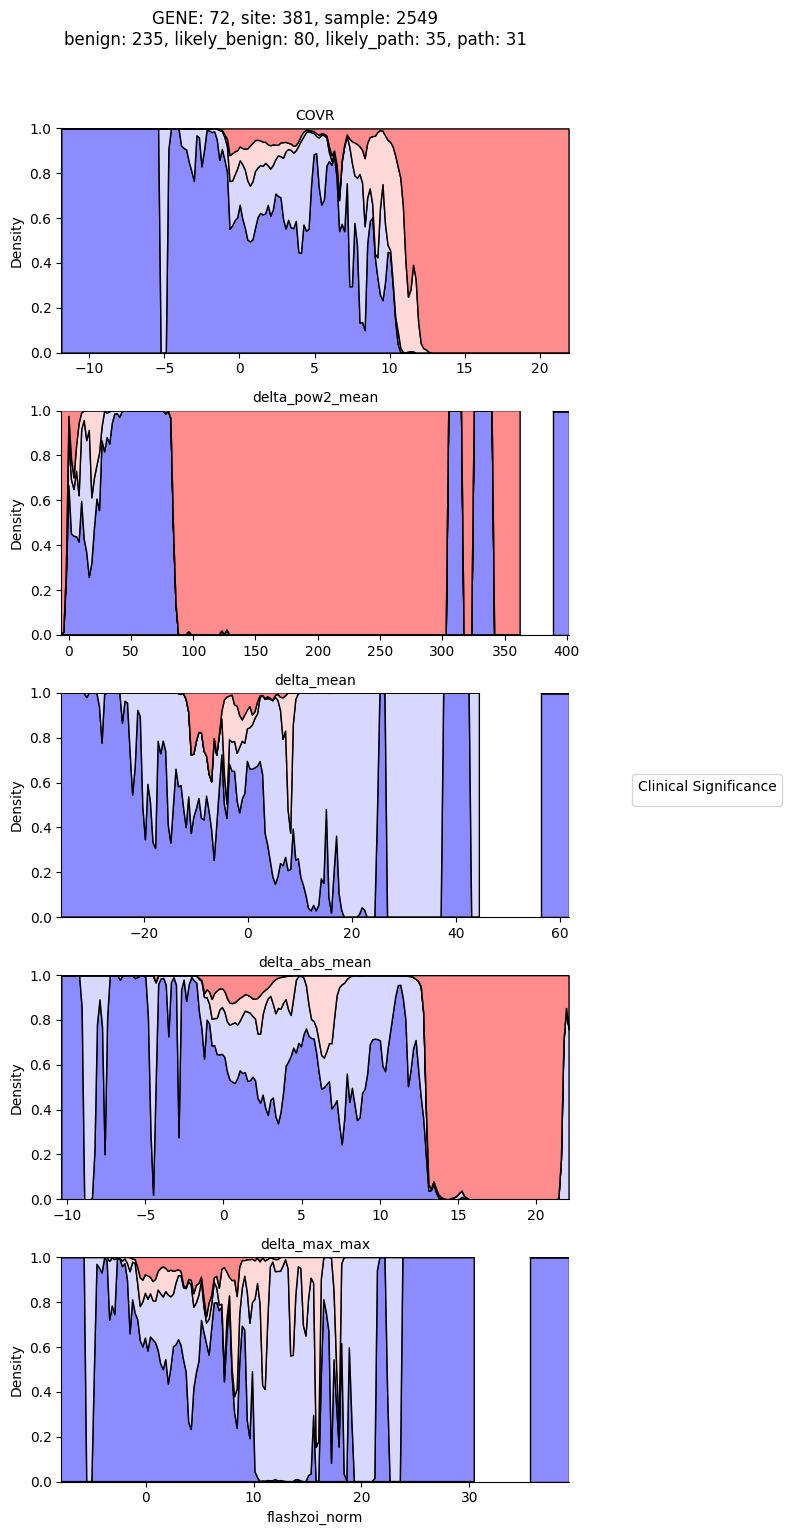

In [12]:
plot_kde(delta_df, 
         x="flashzoi_norm", 
         multiple="fill")

### Grouped by Disease annotation

In [7]:
df = delta_df.loc[(delta_df["CLNSIG_simple"]=="path") & (delta_df["slot"]=="COVR")]
df = va.add_onekg_metadata(df)
df.loc[df["sample"]=="REF", "Super Population"] = "REF"
df.loc[df["sample"]=="REF", "Population"] = "REF"
df.loc[:,"CLNDN"] = df["CLNDN"].str.split("|")

within_site_var = df.explode("CLNDN").reset_index(drop=True).groupby(["CLNDN","site"])["flashzoi"].var().reset_index().sort_values(by="flashzoi", ascending=False)
within_site_var_mean = within_site_var.groupby(["CLNDN"]).agg({"flashzoi":"mean", "site":"nunique"}).sort_values(by="flashzoi", ascending=False).reset_index()
within_site_var.head()

,CLNDN,site,flashzoi
23,Familial_cancer_of_breast,chr22:28734403-28734404_C_A,2.334787
13,Charcot-Marie-Tooth_disease_axonal_type_2Z,chr22:30958684-30958685_C_T,0.740299
16,"Developmental_delay,_impaired_growth,_dysmorph...",chr22:30958684-30958685_C_T,0.740299
93,not_provided,chr22:30958684-30958685_C_T,0.740299
77,Neurodevelopmental_disorder,chr22:30958684-30958685_C_T,0.740299


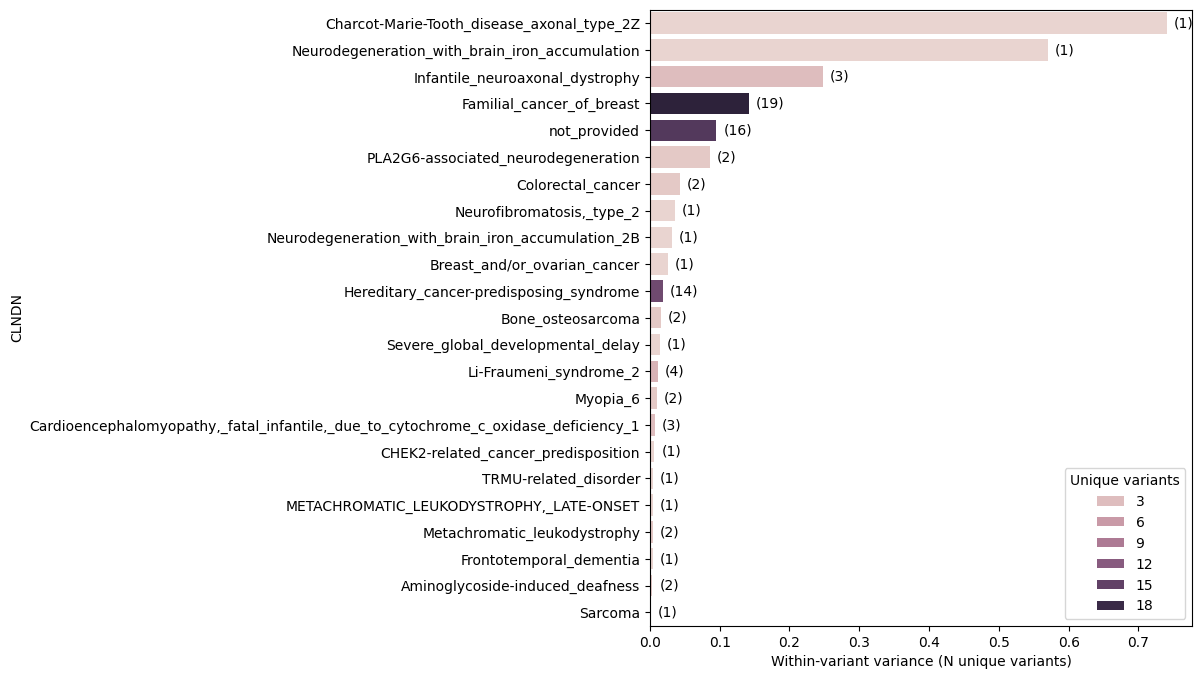

In [8]:
plt.figure(figsize=(7, 8)) 
ax = sns.barplot(data=within_site_var_mean.drop_duplicates(subset=["flashzoi"]),
             y="CLNDN", x="flashzoi",
             hue="site")
plt.legend(title="Unique variants", loc="lower right")
plt.xlabel("Within-variant variance (N unique variants)")
# Add site count annotations
for i, row in enumerate(within_site_var_mean.drop_duplicates(subset=["flashzoi"]).itertuples()):
    ax.text(row.flashzoi + 0.01, i, f"({row.site})", 
            va='center', ha='left')

In [15]:
delta_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
COVR,1942338.0,0.887532,1.056102,0.000000,0.449850,0.645588,0.995963,12.022734
delta_abs_mean,1942338.0,0.000840,0.001114,0.000000,0.000293,0.000501,0.000954,0.016669
delta_max_max,1942338.0,1.876674,3.853368,0.000000,0.368439,0.818568,1.797063,71.295761
delta_mean,1942338.0,-0.000071,0.000557,-0.005755,-0.000103,0.000000,0.000058,0.008153
delta_pow2_mean,1942338.0,0.000198,0.000849,0.000000,0.000004,0.000016,0.000074,0.024490


/tmp/ipykernel_1295409/3203070180.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


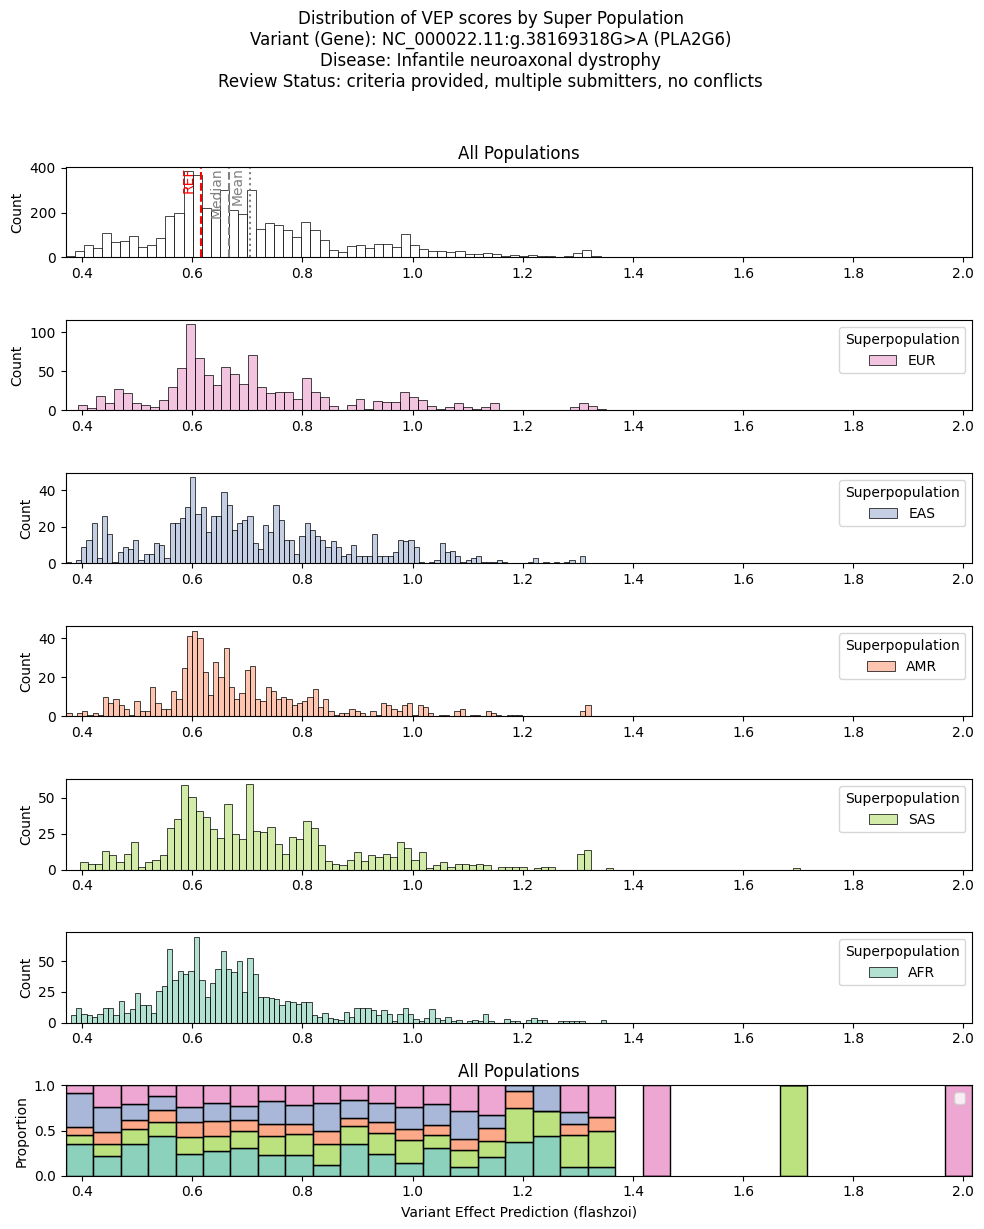

In [61]:
model_name = "flashzoi"
row_selected  = within_site_var.drop_duplicates(
    subset=[model_name]
).iloc[8]

plot_df = delta_df.loc[(delta_df["site"]==row_selected["site"]) & (delta_df["slot"]=="COVR")]
plot_df = va.add_onekg_metadata(plot_df)
bins=100


# Get unique super populations excluding REF
super_pops = plot_df.loc[plot_df["Super Population"]!="REF", "Super Population"].unique()
n_pops = len(super_pops)

# Create figure with subplots - adjust grid size based on number of populations
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(n_pops + 2, 1, height_ratios=[1] * (n_pops + 2))

# Calculate global min and max for consistent x-axis limits
x_min = plot_df[model_name].min()
x_max = plot_df[model_name].max()

# Add histogram with all data in first subplot
ax0 = fig.add_subplot(gs[0])
sns.histplot(plot_df, x=model_name, bins=bins, 
             color="white",
             ax=ax0)
ax0.set_xlabel(None)
# Add REF line
ref_value = plot_df.loc[plot_df["sample"]=="REF", model_name].iloc[0]
ax0.axvline(x=ref_value, color='red', linestyle='--', label='REF')
ax0.text(ref_value - 0.01, ax0.get_ylim()[1], 'REF', color='red', rotation=90, va='top', ha='right')
# Add mean line
ax0.axvline(x=plot_df[model_name].mean(), color='grey', linestyle=':', label='Mean')
ax0.text(plot_df[model_name].mean() - 0.01, ax0.get_ylim()[1], f'Mean', color='grey', rotation=90, va='top', ha='right')
# Add median line 
ax0.axvline(x=plot_df[model_name].median(), color='grey', linestyle='--', label='Median')
ax0.text(plot_df[model_name].median() - 0.01, ax0.get_ylim()[1], f'Median', color='grey', rotation=90, va='top', ha='right')
ax0.set_title("All Populations")
ax0.set_xlim(x_min, x_max)

# Add faceted histograms for each super population
for i, pop in enumerate(super_pops):
    ax = fig.add_subplot(gs[i+1])
    sns.histplot(plot_df.loc[plot_df["Super Population"]==pop], 
                x=model_name, 
                bins=bins,
                hue="Super Population",
                legend=True,
                palette=utils.get_superpop_palette(),
                ax=ax)
    ax.legend(title="Superpopulation", loc="upper right", labels=[pop])
    ax.set_title(None)
    ax.set_xlabel(None)
    ax.set_xlim(x_min, x_max)

ax1 = fig.add_subplot(gs[-1])
sns.histplot(plot_df.loc[plot_df["Super Population"]!="REF"], 
                x=model_name, 
                bins=bins//3,
                hue="Super Population",
                legend=True,
                multiple="fill",
                palette=utils.get_superpop_palette(),
                ax=ax1)
ax1.set_title("All Populations")
ax1.set_xlabel(f"Variant Effect Prediction ({model_name})")
ax1.set_ylabel("Proportion")
ax1.set_xlim(x_min, x_max)

plt.suptitle(f"Distribution of VEP scores by Super Population\nVariant (Gene): {plot_df['CLNHGVS'].iloc[0]} ({plot_df['GENE'].iloc[0]})\nDisease: {row_selected['CLNDN'].replace('_',' ')}\nReview Status: {plot_df['CLNREVSTAT'].iloc[0].replace('_',' ')}", 
             y=1.02)
plt.tight_layout()
plt.legend()

In [15]:
clnsig_simple_counts = delta_df.groupby("GENE")["CLNSIG_super_simple"].nunique().sort_values(ascending=False)
clnsig_simple_counts = clnsig_simple_counts.loc[clnsig_simple_counts>1]
clnsig_simple_counts

GENE
CLCN4    2
DMD      2
PHEX     2
OFD1     2
SHOX     2
Name: CLNSIG_super_simple, dtype: int64

/home/schilder/projects/VEP_DNA/src/vep_analysis.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vep_df['gene_site'] = vep_df[gene_col] + '_' + vep_df[site_col]


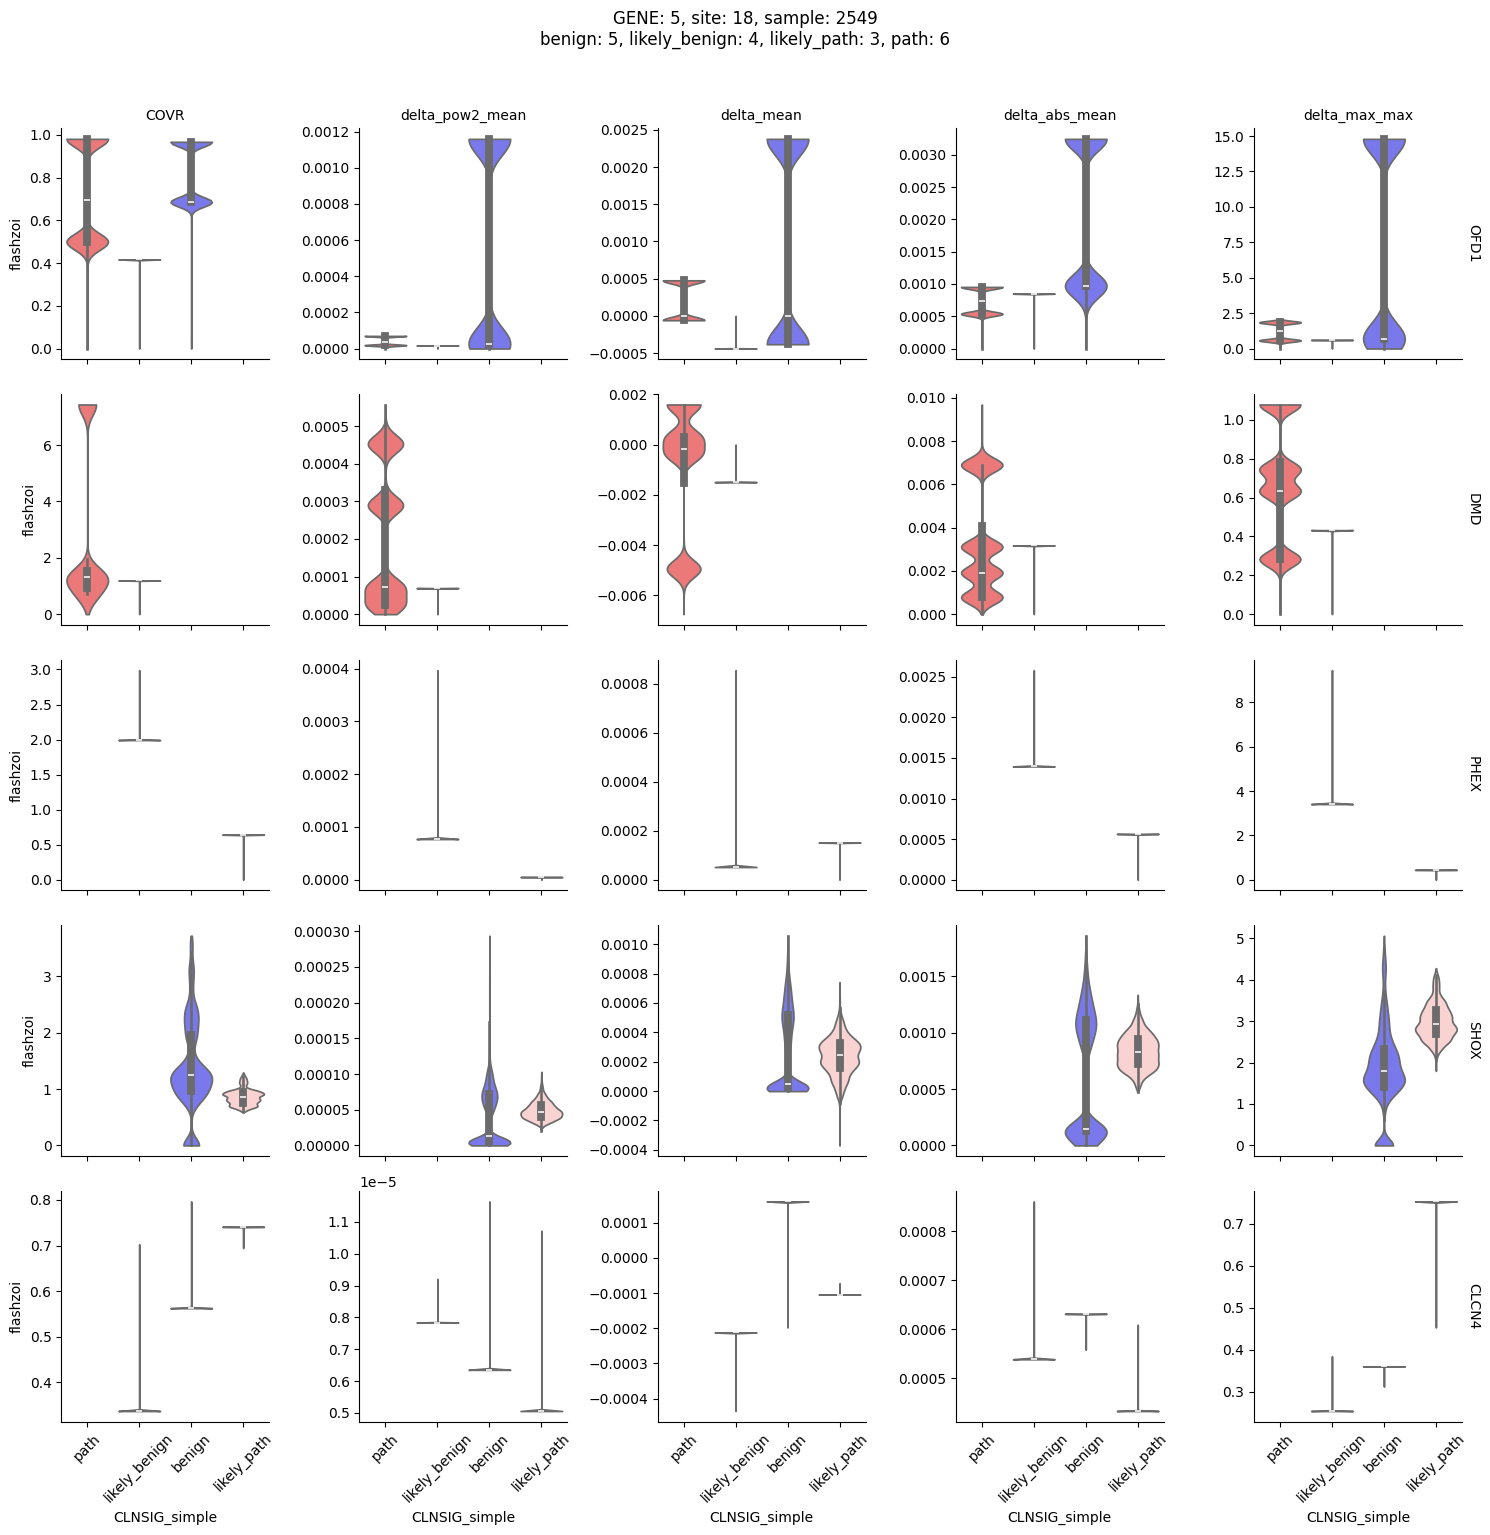

In [17]:
vep_select = delta_df.loc[delta_df["GENE"].isin(clnsig_simple_counts.index)]

g = plot_violin(vep_select, row="GENE")


## Plot individuals across all VEP scores

In [ ]:
import xarray as xr
import glob

variant_set="clinvar_utr_snv_test2"
xr_mfds_paths = glob.glob(os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set,
    "*.zarr"
))

mfds = xr.open_mfdataset(paths=xr_mfds_paths, 
                         concat_dim="sample",
                         combine="nested",
                         preprocess=lambda x: x.where(x.notnull()).sel(slot="COVR")
                  )

mfds_df = mfds.to_dataframe().reset_index().dropna(subset=["flashzoi"])

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

In [20]:
X = mfds_df.pivot(index=["site"], 
                  columns=["sample","ploid"], 
                  values="flashzoi")
X.shape

(722, 5098)

In [21]:
import umap

dr_out = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
from sklearn.decomposition import NMF

dr_out = NMF(n_components=2, 
             max_iter=5000,
             random_state=42).fit_transform(X)

In [28]:
from sklearn.decomposition import PCA

dr_out = PCA(n_components=2, random_state=42).fit_transform(X)

In [29]:
import src.onekg as og

og_meta = og.get_sample_metadata()

In [30]:
import plotly.express as px

dr_df = pd.concat(
    [pd.DataFrame({'sample': X.columns.get_level_values(0)}),
     pd.DataFrame(dr_out, columns=["dim1", "dim2"])],
     axis=1
     ).merge(og_meta, left_on="sample", right_on="Individual ID", how="left")

fig = px.scatter(dr_df, x="dim1", y="dim2", color="Super Population")
fig.show()
